# Cobertura Vacinal no Brasil (2015–2024)
**Projeto G1/G2 — Análise e visualização de dados com Python**

Notebook de análise do projeto. O dashboard interativo está em `app.py` (Streamlit) e a apresentação em `index.html`.

**Sumário:** 1. Introdução · 2. Contextualização · 3. Explicação da base · 4. Leitura · 5. Limpeza e preparação · 6. Engenharia de atributos · 7. Análise exploratória · 8. KPIs · 9. Gráficos · 10. Funcionalidades avançadas (SQLite, correlação, série temporal) · 11. Interpretação · 12. Conclusão

## 1. Introdução ao problema
A queda da cobertura vacinal aumenta o risco de surtos de doenças já controladas. Monitorar a cobertura permite identificar regiões vulneráveis, avaliar campanhas, acompanhar metas de imunização e apoiar políticas públicas.

**Perguntas orientadoras**
1. Quais estados têm menor cobertura?
2. Houve queda da vacinação ao longo do tempo? Em quais períodos?
3. Quais vacinas têm menor adesão e quais estão abaixo da meta?
4. Existem regiões mais vulneráveis?
5. Quais estados exigem maior atenção da saúde pública?

## 2. Contextualização da vacinação
A cobertura vacinal é a proporção da população-alvo que recebeu as doses recomendadas. Cada vacina tem uma **meta** (por exemplo 95% para vacinas de rotina infantil; 80% para outras). Cobertura abaixo da meta enfraquece a imunidade coletiva, e quanto maior a distância da meta, maior o risco de reintrodução de doenças controladas.

> ⚠️ A base usada é **simulada** (fornecida pelo professor). Os números ilustram o método e **não** descrevem a situação real do país.

## 3. Explicação da base de dados
Arquivo: `dados/simulacao_cobertura_vacinal_brasil.csv` — 1 linha por município, mês, vacina e público-alvo.

| Coluna | Descrição |
|---|---|
| ano, mes, data | Período de referência |
| regiao, uf, municipio | Localização |
| vacina | Poliomielite, BCG, Influenza, Hepatite B, COVID-19, Tríplice Viral |
| doses_aplicadas | Doses no período |
| publico_alvo | Crianças, Adolescentes, Adultos, Idosos, Gestantes |
| cobertura_percentual | Cobertura vacinal (%) |
| meta_percentual | Meta de cobertura (80% ou 95%) |
| populacao_alvo | População estimada do público-alvo |
| campanhas | Campanhas realizadas no mês |
| nivel_alerta | Adequado, Atenção ou Crítico |

## 4. Leitura dos dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sqlalchemy import create_engine

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.2f}".format)

IMG = Path("../imagens")
IMG.mkdir(exist_ok=True)

# encoding utf-8-sig remove o BOM que o arquivo traz no início
bruto = pd.read_csv("../dados/simulacao_cobertura_vacinal_brasil.csv", encoding="utf-8-sig")
print(bruto.shape)
bruto.head()

(4440, 14)


,ano,mes,data,regiao,uf,municipio,vacina,doses_aplicadas,publico_alvo,cobertura_percentual,meta_percentual,populacao_alvo,campanhas,nivel_alerta
0,2015,1,2015-01-01,Norte,AM,Manaus,Poliomielite,292274,Adultos,58.72,80,497714,0,Crítico
1,2015,1,2015-01-01,Norte,PA,Belém,BCG,181341,Adultos,81.73,80,221885,0,Adequado
2,2015,1,2015-01-01,Norte,PA,Santarém,Influenza,46148,Crianças,69.03,80,66849,3,Atenção
3,2015,1,2015-01-01,Norte,RO,Porto Velho,Hepatite B,22357,Idosos,75.64,95,29558,0,Crítico
4,2015,1,2015-01-01,Norte,TO,Palmas,COVID-19,393777,Gestantes,86.57,95,454876,4,Atenção


In [2]:
bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ano                   4440 non-null   int64  
 1   mes                   4440 non-null   int64  
 2   data                  4440 non-null   str    
 3   regiao                4440 non-null   str    
 4   uf                    4440 non-null   str    
 5   municipio             4440 non-null   str    
 6   vacina                4440 non-null   str    
 7   doses_aplicadas       4440 non-null   int64  
 8   publico_alvo          4440 non-null   str    
 9   cobertura_percentual  4440 non-null   float64
 10  meta_percentual       4440 non-null   int64  
 11  populacao_alvo        4440 non-null   int64  
 12  campanhas             4440 non-null   int64  
 13  nivel_alerta          4440 non-null   str    
dtypes: float64(1), int64(6), str(7)
memory usage: 729.8 KB


## 5. Limpeza e preparação
Checagens feitas antes de qualquer análise: nulos, duplicatas, tipos, espaços, faixas válidas e consistência interna (cobertura vs doses/população; nível de alerta vs meta).

In [3]:
df = bruto.copy()
df.columns = df.columns.str.strip()

print("Nulos por coluna:\n", df.isna().sum()[df.isna().sum() > 0])
print("Linhas duplicadas:", df.duplicated().sum())

# tipos
df["data"] = pd.to_datetime(df["data"], errors="coerce")
texto = ["regiao", "uf", "municipio", "vacina", "publico_alvo", "nivel_alerta"]
for c in texto:
    df[c] = df[c].astype(str).str.strip()

# faixas válidas
print("Cobertura fora de 0–100:", (~df.cobertura_percentual.between(0, 100)).sum())
print("Populações <= 0:", (df.populacao_alvo <= 0).sum())
print("Datas inválidas:", df.data.isna().sum())

# a data bate com ano/mês?
print("Data inconsistente com ano/mês:", ((df.data.dt.year != df.ano) | (df.data.dt.month != df.mes)).sum())

# cada UF pertence a uma única região?
print("UFs em mais de uma região:", (df.groupby("uf").regiao.nunique() > 1).sum())

Nulos por coluna:
 Series([], dtype: int64)
Linhas duplicadas: 0
Cobertura fora de 0–100: 0
Populações <= 0: 0
Datas inválidas: 0
Data inconsistente com ano/mês: 0
UFs em mais de uma região: 0


In [4]:
# Cobertura = doses / população? (validação do cálculo)
calc = df.doses_aplicadas / df.populacao_alvo * 100
print("Erro máximo |cobertura - doses/pop|:", (calc - df.cobertura_percentual).abs().max().round(4), "p.p.")

# Registros com cobertura exatamente 100% (teto da simulação)
print("Registros com cobertura = 100%:", (df.cobertura_percentual == 100).sum())

# O nível de alerta segue uma regra sobre (cobertura - meta)?
gap = df.cobertura_percentual - df.meta_percentual
regra = np.select([gap >= 0, gap > -15], ["Adequado", "Atenção"], default="Crítico")
print("Regra Adequado (gap>=0) / Atenção (-15<gap<0) / Crítico (gap<=-15) reproduz a coluna:", (regra == df.nivel_alerta).mean() == 1)

Erro máximo |cobertura - doses/pop|: 0.0114 p.p.
Registros com cobertura = 100%: 278
Regra Adequado (gap>=0) / Atenção (-15<gap<0) / Crítico (gap<=-15) reproduz a coluna: True


**Resultado da limpeza:** a base não tem nulos nem duplicatas; os tipos precisaram de ajuste apenas na data e no BOM do arquivo. A cobertura é doses ÷ população (diferença máxima de 0,01 p.p., por arredondamento) e o `nivel_alerta` segue a regra baseada na distância até a meta (≥ 0: Adequado; de −15 a 0: Atenção; ≤ −15: Crítico). Há 278 registros no teto de 100%, que foram **mantidos**, pois são valores plausíveis na simulação.

In [5]:
df = df.dropna().drop_duplicates()
df = df[df.cobertura_percentual.between(0, 100) & (df.populacao_alvo > 0)].reset_index(drop=True)
print(df.shape)

(4440, 14)


## 6. Engenharia de atributos
- `gap_meta`: cobertura − meta (em p.p.; negativo = abaixo da meta)
- `abaixo_meta`: indicador booleano
- `trimestre`: para análise sazonal
- `faixa_cobertura`: classes de cobertura para análise exploratória

In [6]:
df["gap_meta"] = df.cobertura_percentual - df.meta_percentual
df["abaixo_meta"] = df.gap_meta < 0
df["trimestre"] = df.data.dt.quarter
df["faixa_cobertura"] = pd.cut(df.cobertura_percentual, [0, 60, 70, 80, 90, 100],
                               labels=["<60", "60–70", "70–80", "80–90", "90–100"], include_lowest=True)
ORDEM = ["Adequado", "Atenção", "Crítico"]
CORES = {"Adequado": "#2e8b57", "Atenção": "#e6a23c", "Crítico": "#c0392b"}
df[["data", "uf", "vacina", "cobertura_percentual", "meta_percentual", "gap_meta", "abaixo_meta", "faixa_cobertura"]].head()

,data,uf,vacina,cobertura_percentual,meta_percentual,gap_meta,abaixo_meta,faixa_cobertura
0,2015-01-01,AM,Poliomielite,58.72,80,-21.28,True,<60
1,2015-01-01,PA,BCG,81.73,80,1.73,False,80–90
2,2015-01-01,PA,Influenza,69.03,80,-10.97,True,60–70
3,2015-01-01,RO,Hepatite B,75.64,95,-19.36,True,70–80
4,2015-01-01,TO,COVID-19,86.57,95,-8.43,True,80–90


## 7. Análise exploratória

In [7]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ano,4440.00,2019.50,2015.00,2017.00,2019.50,2022.00,2024.00,2.87
mes,4440.00,6.50,1.00,3.75,6.50,9.25,12.00,3.45
data,4440,2019-12-16 10:48:00,2015-01-01 00:00:00,2017-06-23 12:00:00,2019-12-16 12:00:00,2022-06-08 12:00:00,2024-12-01 00:00:00,NaN
doses_aplicadas,4440.00,214186.43,7356.00,110325.25,211400.50,311387.00,498550.00,121767.48
cobertura_percentual,4440.00,84.00,46.97,77.53,84.31,90.94,100.00,9.59
meta_percentual,4440.00,89.12,80.00,80.00,95.00,95.00,95.00,7.32
populacao_alvo,4440.00,254980.21,10152.00,134279.75,256965.00,377522.50,499964.00,140931.95
campanhas,4440.00,0.99,0.00,0.00,1.00,2.00,6.00,0.99
gap_meta,4440.00,-5.12,-48.03,-13.64,-5.29,3.66,20.00,12.06
trimestre,4440.00,2.50,1.00,1.75,2.50,3.25,4.00,1.12


In [8]:
for c in ["regiao", "vacina", "publico_alvo", "nivel_alerta", "meta_percentual", "campanhas"]:
    print(df[c].value_counts().sort_index().to_string(), "\n")
print("Municípios:", df.municipio.nunique(), "| UFs:", df.uf.nunique(), "| Registros por mês:", df.groupby("data").size().unique())

regiao
Centro-Oeste     600
Nordeste         960
Norte            600
Sudeste         1560
Sul              720 

vacina
BCG               760
COVID-19          695
Hepatite B        721
Influenza         769
Poliomielite      782
Tríplice Viral    713 

publico_alvo
Adolescentes    905
Adultos         861
Crianças        871
Gestantes       919
Idosos          884 

nivel_alerta
Adequado    1543
Atenção     1936
Crítico      961 

meta_percentual
80    1740
95    2700 

campanhas
0    1622
1    1658
2     821
3     265
4      58
5      12
6       4 

Municípios: 37 | UFs: 20 | Registros por mês: [37]


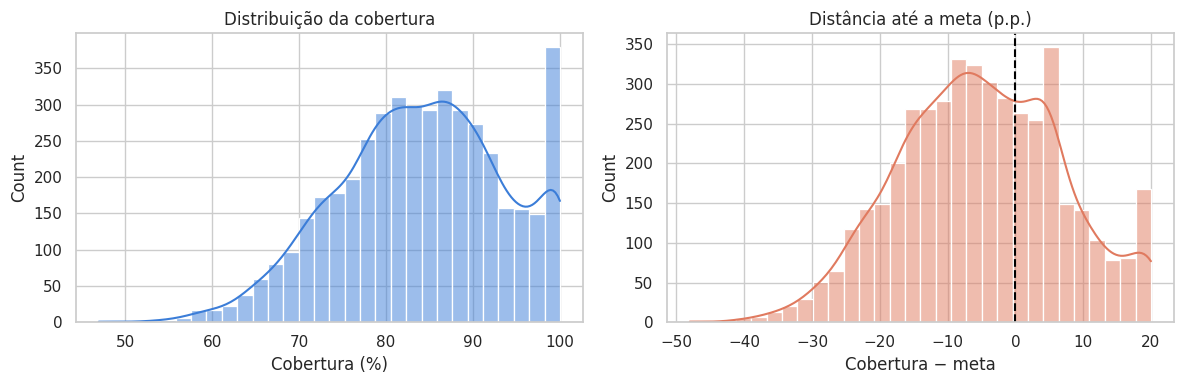

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.cobertura_percentual, bins=30, kde=True, ax=ax[0], color="#3b7dd8")
ax[0].set(title="Distribuição da cobertura", xlabel="Cobertura (%)")
sns.histplot(df.gap_meta, bins=30, kde=True, ax=ax[1], color="#e07a5f")
ax[1].axvline(0, color="black", ls="--")
ax[1].set(title="Distância até a meta (p.p.)", xlabel="Cobertura − meta")
plt.tight_layout(); plt.show()

In [10]:
# O quanto a meta importa? Comparação entre metas de 80% e 95%
df.groupby("meta_percentual").agg(
    registros=("uf", "size"),
    cobertura_media=("cobertura_percentual", "mean"),
    pct_abaixo_meta=("abaixo_meta", lambda s: s.mean() * 100),
    pct_critico=("nivel_alerta", lambda s: (s == "Crítico").mean() * 100),
)

,registros,cobertura_media,pct_abaixo_meta,pct_critico
meta_percentual,,,,
80,1740,83.99,33.51,2.76
95,2700,84.01,85.70,33.81


## 8. KPIs

In [11]:
kpi = {
    "Cobertura vacinal média (%)": df.cobertura_percentual.mean(),
    "Cobertura ponderada pela população (%)": df.doses_aplicadas.sum() / df.populacao_alvo.sum() * 100,
    "Vacina com menor cobertura": df.groupby("vacina").cobertura_percentual.mean().idxmin(),
    "Estado com menor cobertura": df.groupby("uf").cobertura_percentual.mean().idxmin(),
    "Região mais vulnerável": df.groupby("regiao").cobertura_percentual.mean().idxmin(),
    "Registros abaixo da meta (%)": df.abaixo_meta.mean() * 100,
    "Registros em nível crítico (%)": (df.nivel_alerta == "Crítico").mean() * 100,
    "Total de doses aplicadas": int(df.doses_aplicadas.sum()),
}
pd.Series(kpi).to_frame("valor")

,valor
Cobertura vacinal média (%),84.00
Cobertura ponderada pela população (%),84.00
Vacina com menor cobertura,Poliomielite
Estado com menor cobertura,MS
Região mais vulnerável,Sudeste
Registros abaixo da meta (%),65.25
Registros em nível crítico (%),21.64
Total de doses aplicadas,950987728


In [12]:
rank_uf = df.groupby("uf").cobertura_percentual.mean().sort_values().round(2)
rank_vac = df.groupby("vacina").cobertura_percentual.mean().sort_values().round(2)
rank_reg = df.groupby("regiao").cobertura_percentual.mean().sort_values().round(2)
display(rank_reg.to_frame("cobertura_media"), rank_vac.to_frame("cobertura_media"), rank_uf.head(5).to_frame("5 menores UFs"))

,cobertura_media
regiao,
Sudeste,83.74
Nordeste,83.79
Centro-Oeste,83.95
Norte,84.16
Sul,84.77


,cobertura_media
vacina,
Poliomielite,83.41
Tríplice Viral,83.70
BCG,83.89
Hepatite B,84.17
Influenza,84.35
COVID-19,84.55


,5 menores UFs
uf,
MS,82.24
RO,82.62
AM,83.21
DF,83.24
RJ,83.40


## 9. Gráficos
Os gráficos abaixo são salvos em `imagens/` e usados na página `index.html`.

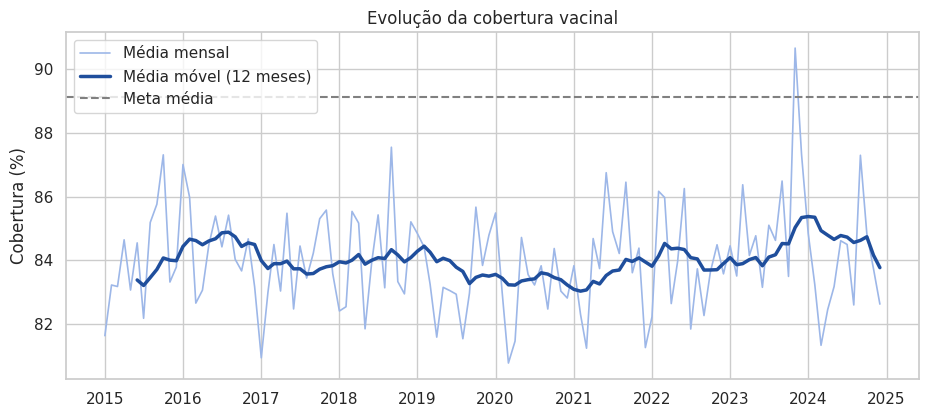

In [13]:
# 1) Linha temporal: cobertura mensal + média móvel de 12 meses
serie = df.groupby("data").cobertura_percentual.mean()
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(serie.index, serie.values, color="#9db7e8", lw=1.2, label="Média mensal")
ax.plot(serie.index, serie.rolling(12, min_periods=6).mean(), color="#1f4e9c", lw=2.5, label="Média móvel (12 meses)")
ax.axhline(df.meta_percentual.mean(), color="gray", ls="--", label="Meta média")
ax.set(title="Evolução da cobertura vacinal", xlabel="", ylabel="Cobertura (%)"); ax.legend()
fig.savefig(IMG / "01_evolucao_temporal.png", dpi=150, bbox_inches="tight"); plt.show()

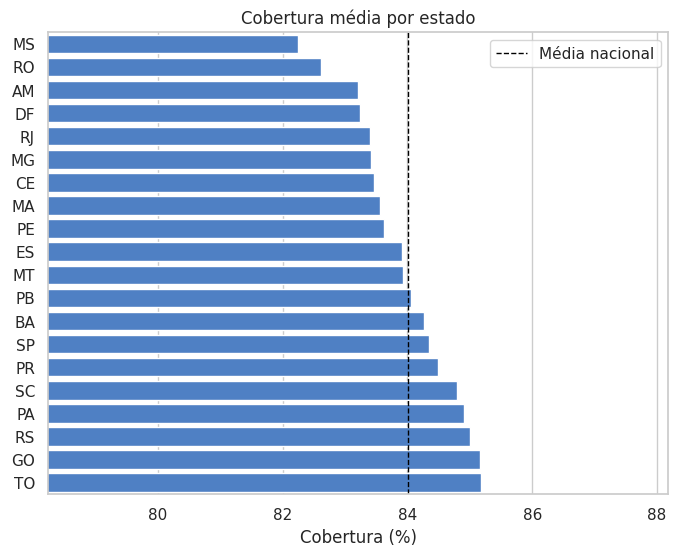

In [14]:
# 2) Barras por estado
ordem = rank_uf
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=ordem.values, y=ordem.index, color="#3b7dd8", ax=ax)
ax.axvline(df.cobertura_percentual.mean(), color="black", ls="--", lw=1, label="Média nacional")
ax.set(title="Cobertura média por estado", xlabel="Cobertura (%)", ylabel="", xlim=(ordem.min() - 4, ordem.max() + 3)); ax.legend()
fig.savefig(IMG / "02_cobertura_por_estado.png", dpi=150, bbox_inches="tight"); plt.show()

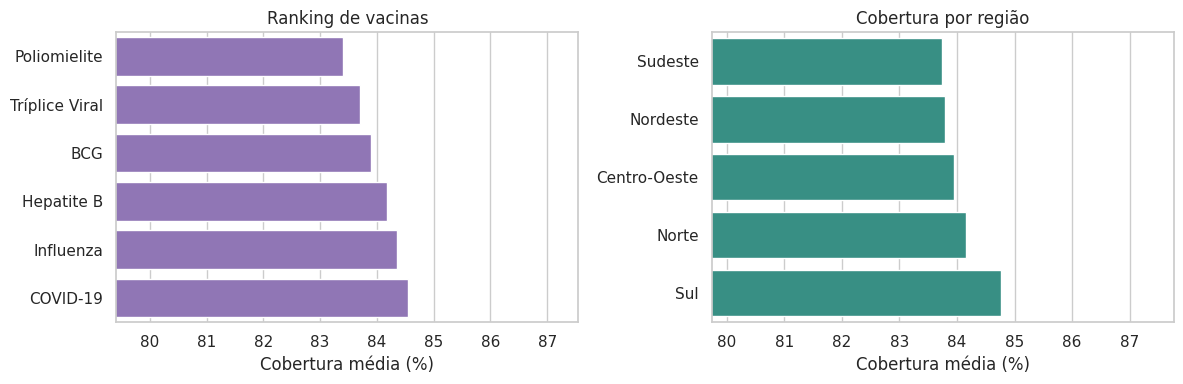

In [15]:
# 3) Barras por vacina e 4) por região
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=rank_vac.values, y=rank_vac.index, color="#8e6bbf", ax=ax[0])
ax[0].set(title="Ranking de vacinas", xlabel="Cobertura média (%)", ylabel="", xlim=(rank_vac.min() - 4, rank_vac.max() + 3))
sns.barplot(x=rank_reg.values, y=rank_reg.index, color="#2a9d8f", ax=ax[1])
ax[1].set(title="Cobertura por região", xlabel="Cobertura média (%)", ylabel="", xlim=(rank_reg.min() - 4, rank_reg.max() + 3))
plt.tight_layout(); fig.savefig(IMG / "03_vacinas_regioes.png", dpi=150, bbox_inches="tight"); plt.show()

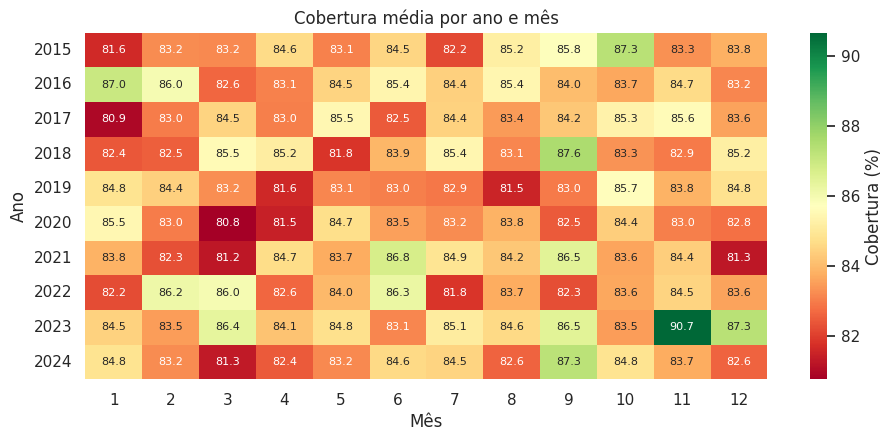

In [16]:
# 5) Heatmap mensal (ano x mês)
heat = df.pivot_table(index="ano", columns="mes", values="cobertura_percentual", aggfunc="mean")
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="RdYlGn", cbar_kws={"label": "Cobertura (%)"}, annot_kws={"size": 8}, ax=ax)
ax.set(title="Cobertura média por ano e mês", xlabel="Mês", ylabel="Ano")
fig.savefig(IMG / "04_heatmap_mensal.png", dpi=150, bbox_inches="tight"); plt.show()

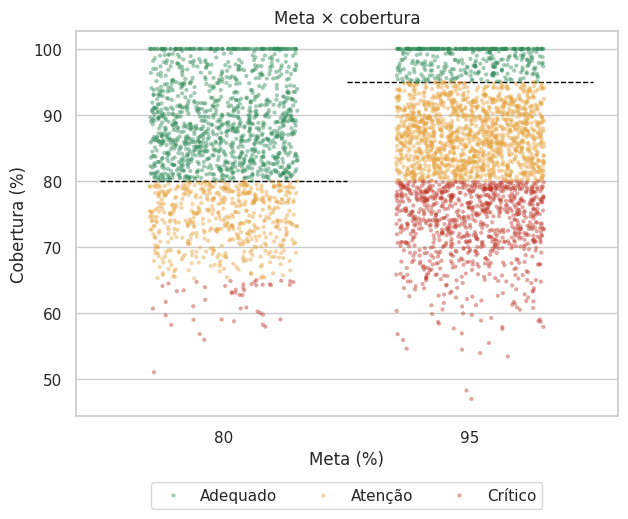

In [17]:
# 6) Dispersão meta x cobertura
fig, ax = plt.subplots(figsize=(7, 5))
sns.stripplot(data=df, x="meta_percentual", y="cobertura_percentual", hue="nivel_alerta", hue_order=ORDEM,
              palette=CORES, alpha=.45, size=3, jitter=.3, ax=ax)
for i, m in enumerate(sorted(df.meta_percentual.unique())):
    ax.hlines(m, i - .5, i + .5, color="black", ls="--", lw=1)
ax.set(title="Meta × cobertura", xlabel="Meta (%)", ylabel="Cobertura (%)")
ax.legend(title="", loc="upper center", bbox_to_anchor=(.5, -.15), ncol=3)
fig.savefig(IMG / "05_dispersao_meta_cobertura.png", dpi=150, bbox_inches="tight"); plt.show()

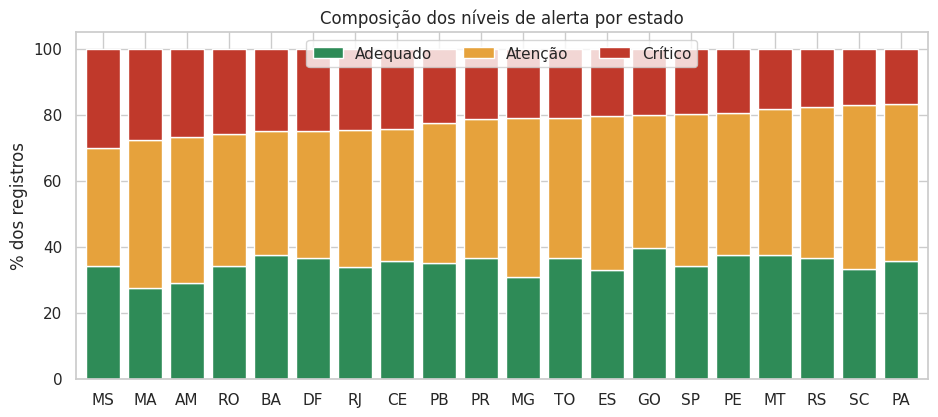

In [18]:
# 7) Níveis de alerta por estado
comp = (pd.crosstab(df.uf, df.nivel_alerta, normalize="index") * 100)[ORDEM].sort_values("Crítico", ascending=False)
fig, ax = plt.subplots(figsize=(11, 4.5))
comp.plot.bar(stacked=True, color=[CORES[c] for c in ORDEM], ax=ax, width=.8)
ax.set(title="Composição dos níveis de alerta por estado", xlabel="", ylabel="% dos registros")
ax.legend(title="", ncol=3, loc="upper center", bbox_to_anchor=(.5, 1.0)); plt.xticks(rotation=0)
fig.savefig(IMG / "06_alertas_por_estado.png", dpi=150, bbox_inches="tight"); plt.show()

## 10. Funcionalidades avançadas
### 10.1 Persistência em banco (SQLAlchemy + SQLite) e modelagem relacional
Duas tabelas: `dim_uf` (UF → região, coordenadas) e `cobertura` (fatos). O dashboard consulta com `JOIN`.

In [19]:
COORD = {"AM": (-3.12, -60.02), "PA": (-1.46, -48.50), "RO": (-8.76, -63.90), "TO": (-10.18, -48.33),
         "BA": (-12.97, -38.51), "PE": (-8.05, -34.88), "CE": (-3.73, -38.52), "MA": (-2.53, -44.30),
         "PB": (-7.12, -34.86), "DF": (-15.79, -47.88), "GO": (-16.68, -49.25), "MT": (-15.60, -56.10),
         "MS": (-20.47, -54.62), "SP": (-23.55, -46.63), "RJ": (-22.91, -43.17), "MG": (-19.92, -43.94),
         "ES": (-20.32, -40.34), "PR": (-25.43, -49.27), "SC": (-27.60, -48.55), "RS": (-30.03, -51.23)}

Path("../database").mkdir(exist_ok=True)
engine = create_engine("sqlite:///../database/vacinacao.db")

dim = df[["uf", "regiao"]].drop_duplicates().copy()
dim["lat"] = dim.uf.map(lambda u: COORD[u][0]); dim["lon"] = dim.uf.map(lambda u: COORD[u][1])
dim.to_sql("dim_uf", engine, if_exists="replace", index=False)

fato = df.drop(columns=["regiao", "faixa_cobertura"]).copy()
fato["data"] = fato.data.dt.strftime("%Y-%m-%d")
fato.to_sql("cobertura", engine, if_exists="replace", index=False)

consulta = """
SELECT d.regiao, c.uf, ROUND(AVG(c.cobertura_percentual), 2) AS cobertura_media,
       ROUND(100.0 * AVG(c.abaixo_meta), 1) AS pct_abaixo_meta
FROM cobertura c JOIN dim_uf d ON c.uf = d.uf
GROUP BY d.regiao, c.uf
ORDER BY cobertura_media LIMIT 8
"""
pd.read_sql(consulta, engine)

,regiao,uf,cobertura_media,pct_abaixo_meta
0,Centro-Oeste,MS,82.24,65.80
1,Norte,RO,82.62,65.80
2,Norte,AM,83.21,70.80
3,Centro-Oeste,DF,83.24,63.30
4,Sudeste,RJ,83.40,66.30
5,Sudeste,MG,83.42,69.20
6,Nordeste,CE,83.47,64.20
7,Nordeste,MA,83.56,72.50


### 10.2 Correlação estatística

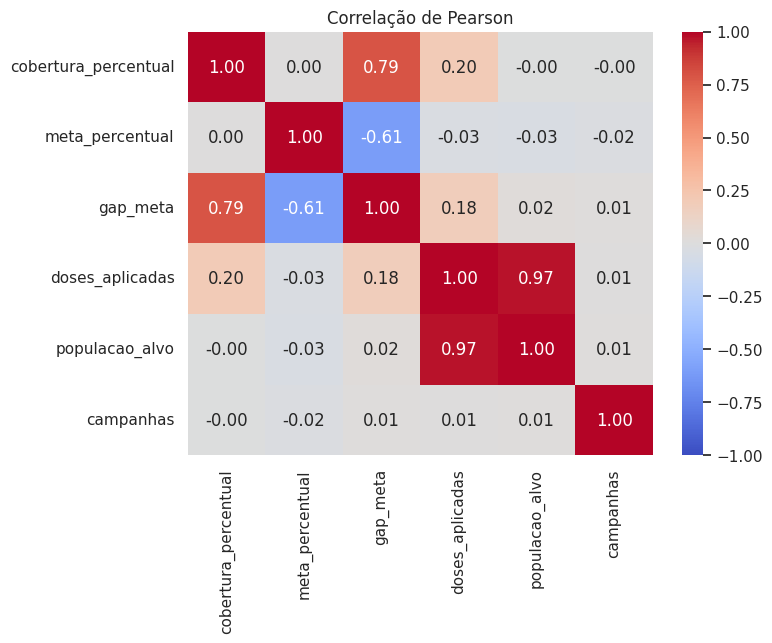

campanhas x cobertura: -0.005
registros por nº de campanhas: {0: 1622, 1: 1658, 2: 821, 3: 265, 4: 58, 5: 12, 6: 4}


In [20]:
cols = ["cobertura_percentual", "meta_percentual", "gap_meta", "doses_aplicadas", "populacao_alvo", "campanhas"]
corr = df[cols].corr()
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlação de Pearson")
fig.savefig(IMG / "07_correlacao.png", dpi=150, bbox_inches="tight"); plt.show()
print("campanhas x cobertura:", round(corr.loc["campanhas", "cobertura_percentual"], 3))
print("registros por nº de campanhas:", df.campanhas.value_counts().sort_index().to_dict())

### 10.3 Série temporal avançada (variação anual e tendência linear)

In [21]:
anual = df.groupby("ano").cobertura_percentual.mean()
var = anual.diff().round(2)
inclinacao, _ = np.polyfit(anual.index, anual.values, 1)
print("Cobertura média anual:\n", anual.round(2).to_dict())
print("\nVariação anual (p.p.):", var.dropna().to_dict())
print(f"\nTendência linear: {inclinacao:+.3f} p.p. por ano")
print("Meses de menor média:", df.groupby("mes").cobertura_percentual.mean().nsmallest(3).round(2).to_dict())

Cobertura média anual:
 {2015: 83.98, 2016: 84.49, 2017: 83.83, 2018: 84.08, 2019: 83.5, 2020: 83.22, 2021: 83.94, 2022: 83.89, 2023: 85.34, 2024: 83.77}

Variação anual (p.p.): {2016: 0.51, 2017: -0.67, 2018: 0.25, 2019: -0.58, 2020: -0.28, 2021: 0.72, 2022: -0.05, 2023: 1.45, 2024: -1.57}

Tendência linear: +0.022 p.p. por ano
Meses de menor média: {4: 83.28, 3: 83.47, 2: 83.73}


## 11. Interpretação dos resultados
- **Menor cobertura por estado:** MS (82,2%), RO (82,6%) e AM (83,2%) têm as menores médias; RS, GO e TO, as maiores (≈ 85%). A distância entre o melhor e o pior estado é de apenas ~2,9 p.p.
- **Regiões:** o Sudeste é a mais vulnerável (83,7%) e o Sul a melhor (84,8%), diferença inferior a 1,1 p.p. Não há uma região claramente destoante.
- **Tempo:** não há queda sustentada. A média anual oscila entre 83,2% (2020) e 85,3% (2023), com tendência linear praticamente nula. A maior queda anual foi em **2024 (−1,6 p.p.)**, depois do melhor ano da série, e 2019–2020 somam −0,9 p.p. de queda acumulada.
- **Vacinas:** Poliomielite tem a menor média (83,4%) e COVID-19 a maior (84,6%), mas a diferença é pequena. **Todas** ficam abaixo da meta média (89,1%).
- **Metas — achado principal:** 65,2% dos registros estão abaixo da meta, mas o problema é **estrutural da meta de 95%**: 85,7% dos registros com meta de 95% ficam abaixo dela (33,8% críticos), contra 33,5% (2,8% críticos) com meta de 80%. A cobertura média é parecida nos dois grupos (~84%); o que muda é a exigência.
- **Estados críticos:** MS (30,0% dos registros críticos), MA (27,5%) e AM (26,7%) concentram a maior fatia de registros críticos; PA (16,7%) e SC (17,1%) têm a menor.
- **Campanhas e população:** a correlação entre campanhas e cobertura é ≈ 0 (−0,005); população-alvo também não explica a cobertura. O valor de 73% para 6 campanhas vem de apenas 4 registros e não é conclusivo.
- **Público-alvo:** diferenças pequenas (Crianças 84,3% × Adultos 83,8%).
- **Limitação:** como a base é simulada, as diferenças parecem ruído em torno de ~84%. Em dados reais, seria preciso testar significância (ANOVA/Kruskal-Wallis) antes de priorizar territórios.

## 12. Conclusão
A cobertura média simulada é de **84,0%** (mesmo valor ponderado por população), **abaixo da meta média de 89,1%**, sem tendência de queda no período 2015–2024. O principal risco está nas **vacinas com meta de 95%**, onde 8 em cada 10 registros não atingem a meta e 1 em cada 3 é crítico.

**Prioridades sugeridas:** (1) MS, MA e AM por concentrarem registros críticos; (2) vacinas com meta de 95%, com foco em Poliomielite e Tríplice Viral (maiores proporções abaixo da meta: 66,4% e 67,2%); (3) monitorar mensalmente a média móvel e os meses com variação negativa.

**Próximos passos:** validar com dados oficiais (SI-PNI/DATASUS), testar significância estatística das diferenças e incluir mapas por município.